**Jaundice Detection from Skin and Eye Images for Children & Adults Using AI**

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

In [18]:
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"
IMG_SIZE = 224
CLASSES = ["normal", "jaundice"]

In [19]:
data = []
labels = []

for label, class_name in enumerate(CLASSES):
    class_path = os.path.join(sayem, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(label)
        except:
            pass

X = np.array(data) / 255.0
y = to_categorical(labels, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=labels
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (608, 224, 224, 3)
Test : (152, 224, 224, 3)


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    brightness_range=[0.8,1.2],
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [23]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Phase 1: freeze

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.6347 - loss: 0.8970 - val_accuracy: 0.7368 - val_loss: 0.7173
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7254 - loss: 0.6179 - val_accuracy: 0.7303 - val_loss: 0.6272
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7173 - loss: 0.6279 - val_accuracy: 0.7368 - val_loss: 0.7088
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7391 - loss: 0.5889 - val_accuracy: 0.7368 - val_loss: 0.7486
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7332 - loss: 0.6009 - val_accuracy: 0.7368 - val_loss: 0.7474
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7054 - loss: 0.6292 - val_accuracy: 0.7368 - val_loss: 0.6930
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7070 - loss: 0.6316 - val_accuracy: 0.7368 - val_loss: 0.7778
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7493 - loss: 0.5924 - val_accuracy: 0.7368 - val_loss:

FINE-TUNING (Accuracy Improvement)

In [25]:
# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7199 - loss: 1.1989 - val_accuracy: 0.7368 - val_loss: 1.3179
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7108 - loss: 0.7000 - val_accuracy: 0.7368 - val_loss: 1.3572
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7171 - loss: 0.6826 - val_accuracy: 0.7368 - val_loss: 1.3598
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7231 - loss: 0.6106 - val_accuracy: 0.7368 - val_loss: 1.3432
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7283 - loss: 0.6099 - val_accuracy: 0.7368 - val_loss: 1.3288
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7760 - loss: 0.5470 - val_accuracy: 0.7368 - val_loss: 1.3151
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7379 - loss: 0.5845 - val_accuracy: 0.7368 - val_loss: 1.2748
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.7160 - loss: 0.6022 - val_accuracy: 0.7368 - val_loss:

RESULT GRAPHS (Accuracy & Loss)

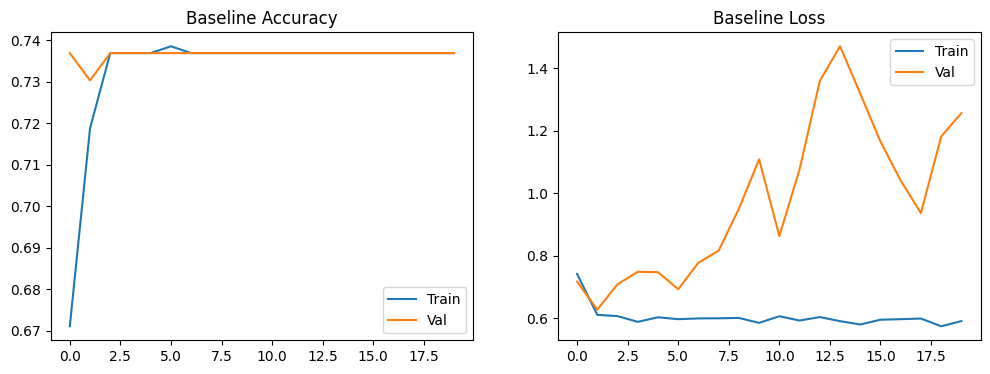

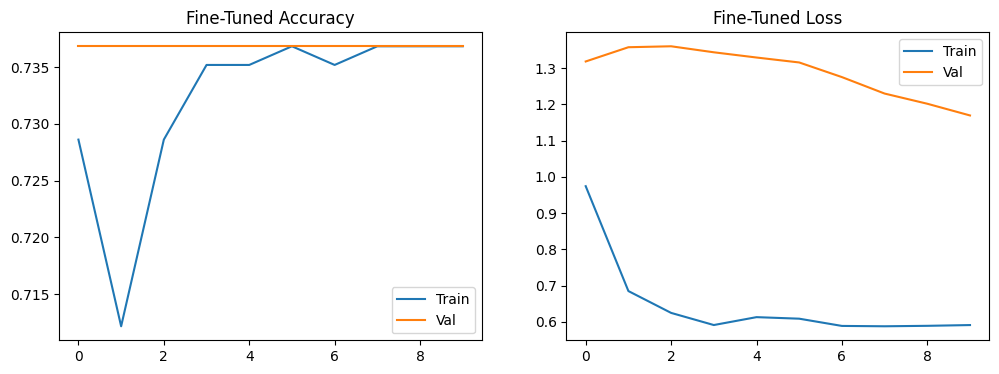

In [26]:
def plot_history(hist, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(history, "Baseline")
plot_history(history_fine, "Fine-Tuned")

Final Evaluation

In [27]:
loss, acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6918 - loss: 1.3562
Final Test Accuracy: 0.7368420958518982


SAVE MODEL

In [28]:
model.save("/content/drive/MyDrive/jaundice_model_njn.h5")
print("Model saved successfully")

Model saved successfully


LOAD MODEL (Later use / Demo)

In [29]:
loaded_model = load_model("/content/drive/MyDrive/jaundice_model_njn.h5")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6918 - loss: 1.3562
Loaded Model Accuracy: 0.7368420958518982


In [30]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

Grad-CAM Function

In [31]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

Load & Prepare a Test Image

In [32]:
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/jaundice/jaundice (1).jpg"  # change image name

img = cv2.imread(sayem)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img, axis=0) / 255.0

Generate Heatmap

In [33]:
heatmap = make_gradcam_heatmap(
    img_array,
    loaded_model,
    last_conv_layer_name="Conv_1"
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_3']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Overlay Heatmap on Image

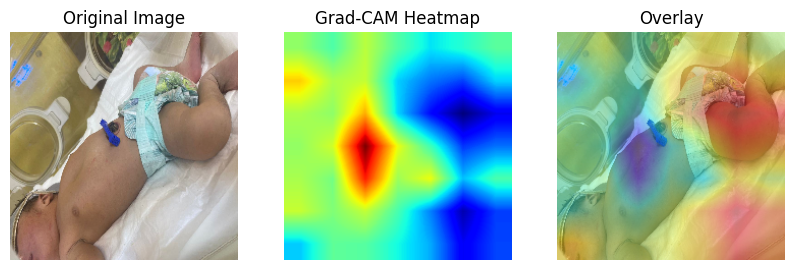

In [34]:
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(superimposed_img)
plt.axis("off")

plt.show()

In [35]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [36]:
# Path (user should adjust if needed)
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"
IMG_SIZE = 224
classes = ["normal", "jaundice"]

records = []

In [38]:
# Extract mean RGB values from each image
for label, cls in enumerate(classes):
    cls_path = os.path.join(sayem, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            r_mean = img[:,:,0].mean()
            g_mean = img[:,:,1].mean()
            b_mean = img[:,:,2].mean()

            records.append([r_mean, g_mean, b_mean, cls])
        except:
            pass

df = pd.DataFrame(records, columns=["R", "G", "B", "Label"])
print(df.head())

            R           G           B   Label
0  152.413823  150.140824  147.345823  normal
1  167.631258  158.025630  132.982940  normal
2  171.276706  150.061643  134.023298  normal
3  172.884148  138.288684  125.444575  normal
4  156.650929  151.458526  148.319236  normal


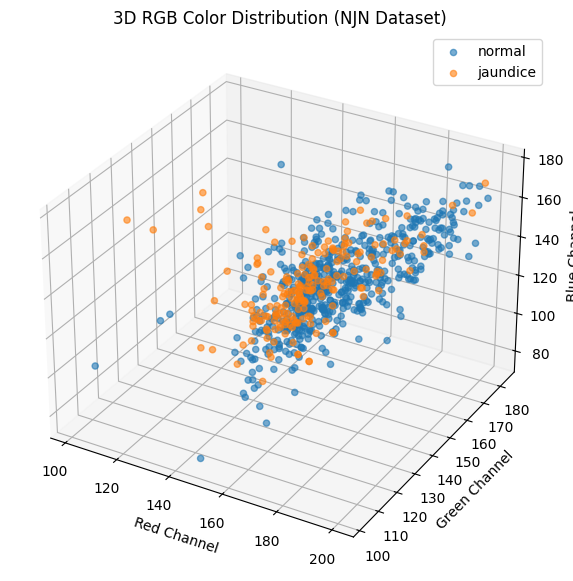

In [39]:
# 3D RGB COLOR SPACE SCATTER
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for cls, color in zip(classes, ['green', 'orange']):
    subset = df[df["Label"] == cls]
    ax.scatter(subset["R"], subset["G"], subset["B"],
               label=cls, alpha=0.6)

ax.set_xlabel("Red Channel")
ax.set_ylabel("Green Channel")
ax.set_zlabel("Blue Channel")
ax.set_title("3D RGB Color Distribution (NJN Dataset)")
ax.legend()
plt.show()

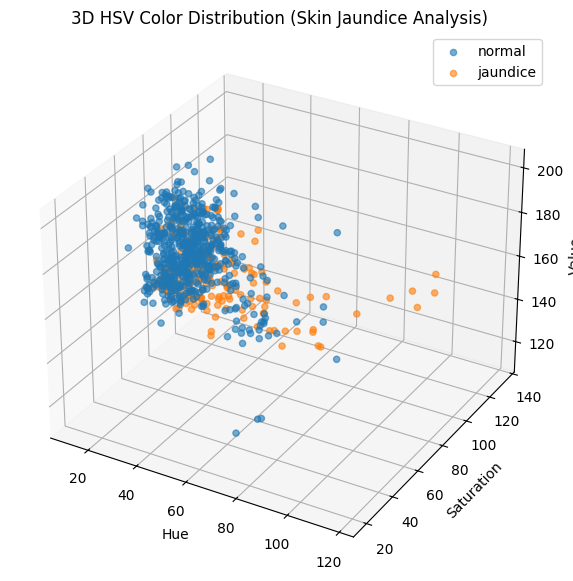

In [41]:
# 3D HSV COLOR SPACE
hsv_records = []

for label, cls in enumerate(classes):
    cls_path = os.path.join(sayem, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            h = img[:,:,0].mean()
            s = img[:,:,1].mean()
            v = img[:,:,2].mean()

            hsv_records.append([h, s, v, cls])
        except:
            pass

df_hsv = pd.DataFrame(hsv_records, columns=["H", "S", "V", "Label"])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for cls, color in zip(classes, ['blue', 'red']):
    subset = df_hsv[df_hsv["Label"] == cls]
    ax.scatter(subset["H"], subset["S"], subset["V"],
               label=cls, alpha=0.6)

ax.set_xlabel("Hue")
ax.set_ylabel("Saturation")
ax.set_zlabel("Value")
ax.set_title("3D HSV Color Distribution (Skin Jaundice Analysis)")
ax.legend()
plt.show()

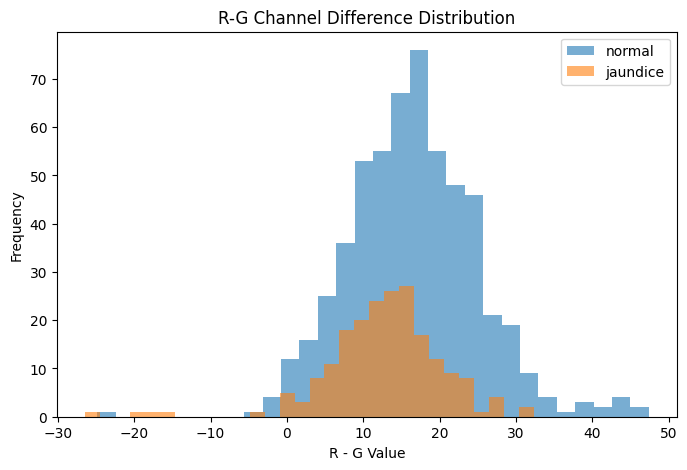

In [43]:
# FEATURE SEPARABILITY PLOT (R-G Difference)
df["R_minus_G"] = df["R"] - df["G"]

plt.figure(figsize=(8,5))
for cls, color in zip(classes, ['green', 'orange']):
    subset = df[df["Label"] == cls]
    plt.hist(subset["R_minus_G"], bins=30, alpha=0.6, label=cls)

plt.title("R-G Channel Difference Distribution")
plt.xlabel("R - G Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()